# Climate Headlines — Text Analysis & Event Study

This notebook carries the analysis forward from `eda.ipynb`. It covers:

1. **Re-load & save processed datasets** — save clean CSVs so downstream steps are fast to re-run.
2. **VADER sentiment scoring** — assign an emotional tone score to every climate-related headline.
3. **Time-series overview** — how do coverage frequency and sentiment evolve across 2012–2021?
4. **Event-study windows** — how does coverage change in the three months around three major disasters?
5. **Topic modelling (LDA)** — what recurring themes appear in climate coverage?
6. **Disaster severity correlation** — do bigger disasters trigger more or gloomier coverage?
7. **Summary comparison table** — side-by-side audit of HuffPost vs ABC responsiveness.

**Three case-study events:**
| Event | Country | Start | Deaths | Damage |
|---|---|---|---|---|
| Black Summer (Currowan bushfires) | Australia | Sep 2019 | 32 | \$2 B |
| Camp Fire (California) | USA | Nov 2018 | 88 | \$16.5 B |
| Hurricane Harvey | USA | Aug 2017 | 88 | \$95 B |

**Research Questions:**
- RQ1: Does the frequency of *climate-related* headlines increase after a disaster?
- RQ2: Does the sentiment of *climate-related* headlines become more negative after a disaster?

## Setup
Install any missing libraries and import everything needed for the full analysis pipeline.

In [1]:
import subprocess, sys

def install(pkg):
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

for pkg in ["kagglehub", "pandas", "matplotlib", "seaborn",
            "vaderSentiment", "nltk", "scikit-learn"]:
    install(pkg)

import os, json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import kagglehub
import nltk
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from scipy import stats

nltk.download("punkt", quiet=True)
nltk.download("stopwords", quiet=True)
nltk.download("punkt_tab", quiet=True)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (13, 5)

# Paths
BASE_DIR  = os.path.dirname(os.path.abspath("text_analysis.ipynb"))
PROCESSED = os.path.join(BASE_DIR, "data", "processed")
OUTPUTS   = os.path.join(BASE_DIR, "outputs")
os.makedirs(PROCESSED, exist_ok=True)
os.makedirs(OUTPUTS,   exist_ok=True)

CLIMATE_KEYWORDS = [
    "climate change", "global warming", "sea level",
    "climate", "flood", "wildfire", "bushfire", "drought",
    "hurricane", "cyclone", "heatwave", "emissions", "carbon"
]

print("Setup complete.")


[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 26.1 -> 26.1.1
[notice] To update, run: pip install --upgrade pip


Setup complete.


---
## Step 1 — Re-load & Save Processed Datasets

We reload all three datasets using the same filters applied in `eda.ipynb`, then save clean CSV files to `data/processed/`. This means later steps can skip the slow download and re-run instantly.

**What to look for:** Confirmation that each file is saved, and that the row counts match what we found in EDA — approximately 1,811 climate headlines for HuffPost and 15,534 for ABC.

In [2]:
# --- HuffPost (US) ---
KEEP_CATS = ["U.S. NEWS", "POLITICS", "WORLD NEWS", "ENVIRONMENT", "GREEN",
             "BUSINESS", "SCIENCE", "MEDIA", "IMPACT", "THE WORLDPOST"]

path1 = kagglehub.dataset_download("rmisra/news-category-dataset")
jsonl_file = [f for f in os.listdir(path1) if f.endswith(".json")][0]
with open(os.path.join(path1, jsonl_file), "r", encoding="utf-8") as f:
    news_raw = pd.DataFrame([json.loads(line) for line in f])

news_usa = (
    news_raw[news_raw["category"].isin(KEEP_CATS)][["headline", "date"]].copy()
)
news_usa["date"] = pd.to_datetime(news_usa["date"], errors="coerce")
news_usa = news_usa[
    (news_usa["date"].dt.year >= 2012) & (news_usa["date"].dt.year <= 2021)
].rename(columns={"date": "publish_date"}).drop_duplicates().reset_index(drop=True)

# Climate-filtered subset — keep publish_date as datetime
hp_lower = news_usa["headline"].str.lower()
climate_mask_hp = hp_lower.apply(lambda t: any(kw in t for kw in CLIMATE_KEYWORDS))
huffpost_climate = news_usa[climate_mask_hp].copy()

news_usa.to_csv(os.path.join(PROCESSED, "huffpost_all.csv"), index=False)
huffpost_climate.to_csv(os.path.join(PROCESSED, "huffpost_climate.csv"), index=False)

print(f"HuffPost total (filtered):   {len(news_usa):,}")
print(f"HuffPost climate headlines:  {len(huffpost_climate):,}")

HuffPost total (filtered):   61,704
HuffPost climate headlines:  1,811


In [3]:
# --- ABC Australia ---
path2 = kagglehub.dataset_download("therohk/million-headlines")
csv_file = [f for f in os.listdir(path2) if f.endswith(".csv")][0]
news_australia = pd.read_csv(os.path.join(path2, csv_file))

news_australia["publish_date"] = pd.to_datetime(
    news_australia["publish_date"].astype(str), format="%Y%m%d", errors="coerce"
)
news_australia = (
    news_australia[
        (news_australia["publish_date"].dt.year >= 2012) &
        (news_australia["publish_date"].dt.year <= 2021)
    ].drop_duplicates().reset_index(drop=True)
)

abc_lower = news_australia["headline_text"].str.lower()
climate_mask_abc = abc_lower.apply(lambda t: any(kw in t for kw in CLIMATE_KEYWORDS))
abc_climate = news_australia[climate_mask_abc].copy()

news_australia.to_csv(os.path.join(PROCESSED, "abc_all.csv"), index=False)
abc_climate.to_csv(os.path.join(PROCESSED, "abc_climate.csv"), index=False)

print(f"ABC total (filtered):        {len(news_australia):,}")
print(f"ABC climate headlines:       {len(abc_climate):,}")

ABC total (filtered):        581,168
ABC climate headlines:       15,534


In [4]:
# --- EM-DAT ---
emdat_path = os.path.join(BASE_DIR, "data", "EMDAT.csv")
emdat_raw = pd.read_csv(emdat_path, sep=";", encoding="latin-1", low_memory=False)
emdat = emdat_raw[emdat_raw["Disaster Group"] == "Natural"].copy().reset_index(drop=True)

for col in ["Total Deaths", "No. Affected", "Total Affected",
            "Total Damage ('000 US$)", "Total Damage, Adjusted ('000 US$)"]:
    if col in emdat.columns:
        emdat[col] = (
            emdat[col].astype(str)
            .str.replace(",", ".", regex=False)
            .str.replace(" ", "", regex=False)
            .pipe(pd.to_numeric, errors="coerce")
        )

emdat.to_csv(os.path.join(PROCESSED, "emdat_clean.csv"), index=False)
print(f"EM-DAT (Natural disasters):  {len(emdat):,} events")
print(emdat["ISO"].value_counts().to_string())

EM-DAT (Natural disasters):  300 events
ISO
USA    260
AUS     40


---
## Step 2 — VADER Sentiment Scoring

We use a tool called **VADER** (Valence Aware Dictionary and sEntiment Reasoner) to automatically score the emotional tone of each climate-related headline. VADER was designed specifically for short social-media and news text, making it well suited to headlines.

VADER returns four scores per headline:
- **neg / neu / pos** — fraction of the text that reads as negative, neutral, or positive
- **compound** — a single summary score from **−1 (most negative)** to **+1 (most positive)**

All subsequent analysis uses the compound score. This step runs **only on the climate-filtered headlines**, not on all news from either outlet.

**What to look for:** Most headlines will score near 0 (neutral). A persistent negative drift around disaster events would support Research Question 2.

In [5]:
sia = SentimentIntensityAnalyzer()

def score_headlines(df, text_col):
    scores = df[text_col].apply(lambda h: sia.polarity_scores(str(h)))
    return df.assign(
        neg=scores.apply(lambda s: s["neg"]),
        neu=scores.apply(lambda s: s["neu"]),
        pos=scores.apply(lambda s: s["pos"]),
        compound=scores.apply(lambda s: s["compound"]),
    )

huffpost_sent = score_headlines(huffpost_climate.copy(), "headline")
abc_sent      = score_headlines(abc_climate.copy(),     "headline_text")

huffpost_sent.to_csv(os.path.join(PROCESSED, "huffpost_sentiment.csv"), index=False)
abc_sent.to_csv(os.path.join(PROCESSED, "abc_sentiment.csv"), index=False)

print("HuffPost compound — mean:", round(huffpost_sent["compound"].mean(), 4),
      " std:", round(huffpost_sent["compound"].std(), 4))
print("ABC compound     — mean:", round(abc_sent["compound"].mean(), 4),
      " std:", round(abc_sent["compound"].std(), 4))

HuffPost compound — mean: -0.0939  std: 0.3602
ABC compound     — mean: -0.0618  std: 0.3008


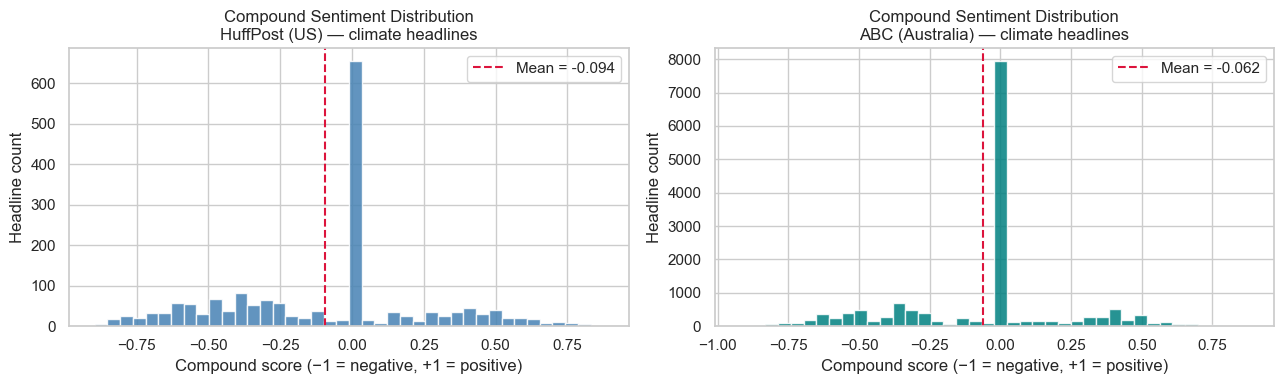

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=False)

for ax, df, label, color in [
    (axes[0], huffpost_sent, "HuffPost (US)",    "steelblue"),
    (axes[1], abc_sent,      "ABC (Australia)", "teal"),
]:
    ax.hist(df["compound"], bins=40, color=color, edgecolor="white", alpha=0.85)
    ax.axvline(df["compound"].mean(), color="crimson", linestyle="--",
               label=f"Mean = {df['compound'].mean():.3f}")
    ax.set_title(f"Compound Sentiment Distribution\n{label} — climate headlines")
    ax.set_xlabel("Compound score (−1 = negative, +1 = positive)")
    ax.set_ylabel("Headline count")
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "fig_sentiment_distribution.png"), dpi=150)
plt.show()

---
## Step 3 — Time-Series Overview

**Research Question 1:** Does the frequency of *climate-related* headlines increase after a disaster?  
**Research Question 2:** Does the sentiment of *climate-related* headlines become more negative after a disaster?

To answer these at a broad level, we look at two monthly time series across the full 2012–2021 period:

- **Climate headline share** — the percentage of each outlet's monthly output that contains at least one climate keyword. This controls for the fact that ABC publishes far more headlines in total than HuffPost.
- **Mean VADER compound score** — the average sentiment of climate-related headlines each month.

Vertical markers show the timing of our three case-study events. **What to look for:** peaks in share and dips in sentiment near those markers.

In [7]:
# Ensure publish_date is datetime for both sentiment frames
huffpost_sent["publish_date"] = pd.to_datetime(huffpost_sent["publish_date"])
abc_sent["publish_date"]      = pd.to_datetime(abc_sent["publish_date"])
news_usa["publish_date"]      = pd.to_datetime(news_usa["publish_date"])
news_australia["publish_date"] = pd.to_datetime(news_australia["publish_date"])

# Monthly total headline counts (denominator for share calculation)
hp_monthly_total  = news_usa.set_index("publish_date").resample("M").size().rename("total")
abc_monthly_total = news_australia.set_index("publish_date").resample("M").size().rename("total")

# Monthly climate counts and mean sentiment
hp_monthly = (
    huffpost_sent.set_index("publish_date")
    .resample("M")["compound"]
    .agg(["count", "mean"])
    .rename(columns={"count": "climate_count", "mean": "mean_compound"})
)
abc_monthly = (
    abc_sent.set_index("publish_date")
    .resample("M")["compound"]
    .agg(["count", "mean"])
    .rename(columns={"count": "climate_count", "mean": "mean_compound"})
)

hp_monthly["share"]  = hp_monthly["climate_count"]  / hp_monthly_total  * 100
abc_monthly["share"] = abc_monthly["climate_count"] / abc_monthly_total * 100

print("HuffPost monthly sample:")
print(hp_monthly.tail(3))
print("\nABC monthly sample:")
print(abc_monthly.tail(3))

HuffPost monthly sample:
              climate_count  mean_compound     share
publish_date                                        
2021-10-31                3       0.222500  3.529412
2021-11-30                7       0.141071  5.737705
2021-12-31                4      -0.243250  3.846154

ABC monthly sample:
              climate_count  mean_compound     share
publish_date                                        
2021-10-31               27      -0.047078  2.732794
2021-11-30               46      -0.064967  4.752066
2021-12-31               39      -0.071215  3.564899


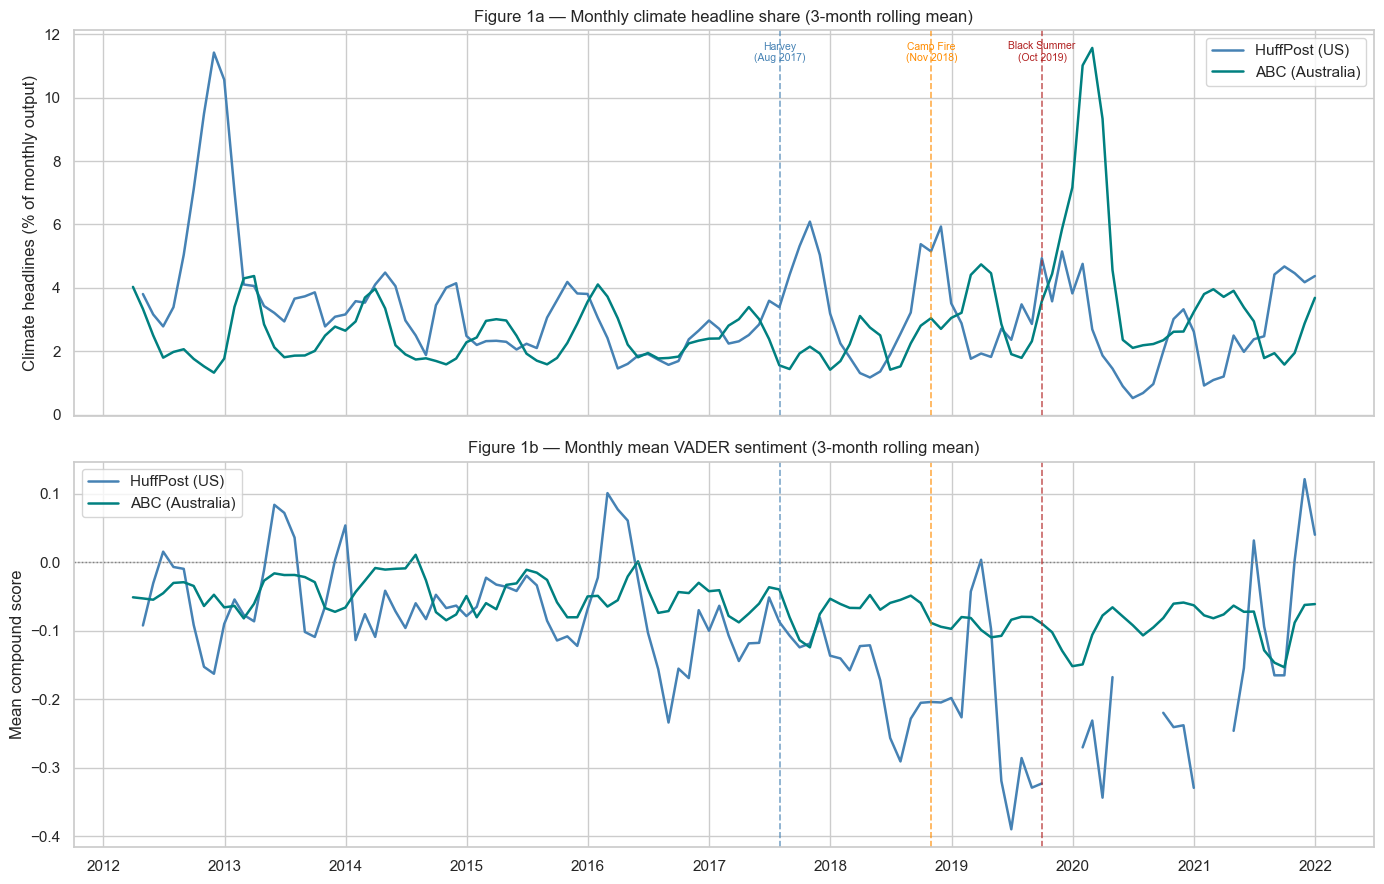

In [8]:
# Case-study event markers
EVENTS = [
    {"label": "Harvey\n(Aug 2017)",    "date": "2017-08-01", "color": "steelblue"},
    {"label": "Camp Fire\n(Nov 2018)",  "date": "2018-11-01", "color": "darkorange"},
    {"label": "Black Summer\n(Oct 2019)", "date": "2019-10-01", "color": "firebrick"},
]

fig, axes = plt.subplots(2, 1, figsize=(14, 9), sharex=True)

# --- Panel 1: Climate headline share ---
ax = axes[0]
ax.plot(hp_monthly.index,  hp_monthly["share"].rolling(3).mean(),
        color="steelblue", lw=1.8, label="HuffPost (US)")
ax.plot(abc_monthly.index, abc_monthly["share"].rolling(3).mean(),
        color="teal",      lw=1.8, label="ABC (Australia)")
for ev in EVENTS:
    ax.axvline(pd.Timestamp(ev["date"]), color=ev["color"],
               linestyle="--", alpha=0.7, lw=1.2)
    ax.text(pd.Timestamp(ev["date"]), ax.get_ylim()[1] * 0.92,
            ev["label"], ha="center", fontsize=7.5, color=ev["color"])
ax.set_ylabel("Climate headlines (% of monthly output)")
ax.set_title("Figure 1a — Monthly climate headline share (3-month rolling mean)")
ax.legend()

# --- Panel 2: Mean VADER compound sentiment ---
ax = axes[1]
ax.plot(hp_monthly.index,  hp_monthly["mean_compound"].rolling(3).mean(),
        color="steelblue", lw=1.8, label="HuffPost (US)")
ax.plot(abc_monthly.index, abc_monthly["mean_compound"].rolling(3).mean(),
        color="teal",      lw=1.8, label="ABC (Australia)")
ax.axhline(0, color="grey", linestyle=":", lw=1)
for ev in EVENTS:
    ax.axvline(pd.Timestamp(ev["date"]), color=ev["color"],
               linestyle="--", alpha=0.7, lw=1.2)
ax.set_ylabel("Mean compound score")
ax.set_title("Figure 1b — Monthly mean VADER sentiment (3-month rolling mean)")
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "fig_timeseries_overview.png"), dpi=150)
plt.show()

---
## Step 4 — Event-Study Windows

An **event study** asks: does something change *around* a specific event, compared to a "business as usual" baseline?

For each of our three disasters, we:
1. Extract the **event window** — the three months before and three months after the disaster peak (7 months total).
2. Build a **control window** — the same seven calendar months, averaged across all *non-disaster* years in 2012–2021 for the relevant country.
3. Compare headline share and sentiment between the event and control.

We check **both outlets** for each event — for example, does ABC (Australia) spike more than HuffPost (US) during the Black Summer? Does HuffPost respond more strongly to Hurricane Harvey?

**What to look for:** If the event window clearly diverges from the control, that is evidence that the disaster influenced media coverage.

In [9]:
def get_event_window(monthly_df, anchor_year, anchor_month, lag=3):
    """Return rows for months t-lag to t+lag relative to the anchor."""
    anchor = pd.Period(year=anchor_year, month=anchor_month, freq="M")
    periods = [anchor + i for i in range(-lag, lag + 1)]
    idx = monthly_df.index.to_period("M")
    return monthly_df[idx.isin(periods)].copy()


def get_control_window(monthly_df, anchor_month, anchor_year, lag=3, iso=None):
    """
    Average the same 7 calendar-month window across all years except the
    event year. Returns a DataFrame with the same month-offset index.
    """
    # Identify disaster years for this country from EM-DAT so they can be excluded
    if iso is not None:
        disaster_years = set(
            emdat[emdat["ISO"] == iso]["Start Year"].dropna().astype(int).tolist()
        )
    else:
        disaster_years = set()

    target_months = [(anchor_month - lag + i - 1) % 12 + 1 for i in range(2 * lag + 1)]

    idx = monthly_df.index
    mask = (
        idx.month.isin(target_months) &
        ~idx.year.isin(disaster_years | {anchor_year})
    )
    control = monthly_df[mask].copy()
    control["offset"] = control.index.month.map(
        lambda m: target_months.index(m) - lag
    )
    return control.groupby("offset")[["share", "mean_compound"]].mean()


print("Helper functions defined.")

Helper functions defined.


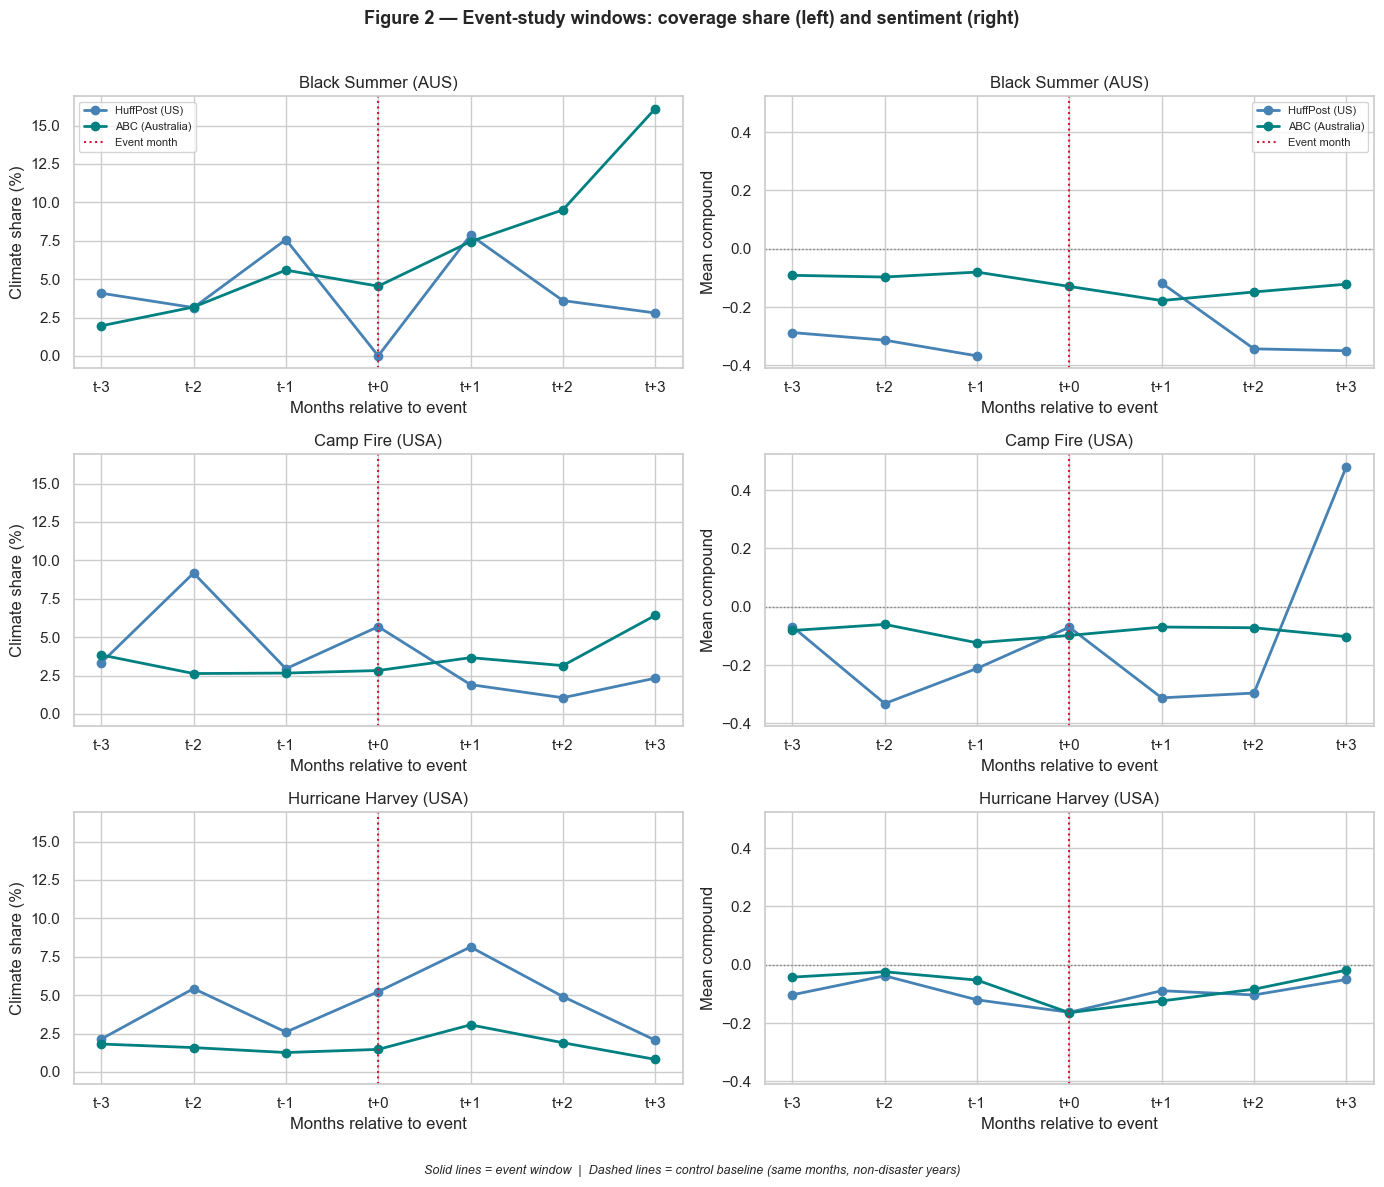

In [10]:
CASE_STUDIES = [
    {"name": "Black Summer (AUS)",   "year": 2019, "month": 10, "iso": "AUS"},
    {"name": "Camp Fire (USA)",       "year": 2018, "month": 11, "iso": "USA"},
    {"name": "Hurricane Harvey (USA)","year": 2017, "month":  8, "iso": "USA"},
]

OUTLETS = [
    {"label": "HuffPost (US)",    "monthly": hp_monthly,  "color": "steelblue", "iso": "USA"},
    {"label": "ABC (Australia)",  "monthly": abc_monthly, "color": "teal",      "iso": "AUS"},
]

LAG = 3
offsets = list(range(-LAG, LAG + 1))

fig, axes = plt.subplots(len(CASE_STUDIES), 2, figsize=(14, 12), sharey="col")
fig.suptitle("Figure 2 — Event-study windows: coverage share (left) and sentiment (right)",
             fontsize=13, fontweight="bold")

for row, cs in enumerate(CASE_STUDIES):
    ax_share = axes[row, 0]
    ax_sent  = axes[row, 1]

    for outlet in OUTLETS:
        mdf = outlet["monthly"]
        ev_win = get_event_window(mdf, cs["year"], cs["month"], LAG)
        ev_win["offset"] = list(range(-LAG, -LAG + len(ev_win)))

        ctrl = get_control_window(mdf, cs["month"], cs["year"], LAG, iso=outlet["iso"])

        # Share
        ax_share.plot(ev_win["offset"], ev_win["share"],
                      color=outlet["color"], lw=2, marker="o", label=outlet["label"])
        ax_share.plot(ctrl.index, ctrl["share"],
                      color=outlet["color"], lw=1.5, linestyle="--", alpha=0.6)

        # Sentiment
        ax_sent.plot(ev_win["offset"], ev_win["mean_compound"],
                     color=outlet["color"], lw=2, marker="o", label=outlet["label"])
        ax_sent.plot(ctrl.index, ctrl["mean_compound"],
                     color=outlet["color"], lw=1.5, linestyle="--", alpha=0.6)

    for ax in [ax_share, ax_sent]:
        ax.axvline(0, color="crimson", linestyle=":", lw=1.5, label="Event month")
        ax.set_xticks(offsets)
        ax.set_xticklabels([f"t{o:+d}" for o in offsets])
        ax.set_xlabel("Months relative to event")

    ax_share.set_ylabel("Climate share (%)")
    ax_share.set_title(cs["name"])
    ax_sent.set_ylabel("Mean compound")
    ax_sent.set_title(cs["name"])
    ax_sent.axhline(0, color="grey", linestyle=":", lw=1)
    if row == 0:
        ax_share.legend(fontsize=8)
        ax_sent.legend(fontsize=8)

fig.text(0.5, 0.01,
         "Solid lines = event window  |  Dashed lines = control baseline (same months, non-disaster years)",
         ha="center", fontsize=9, style="italic")

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.savefig(os.path.join(OUTPUTS, "fig_event_study.png"), dpi=150)
plt.show()

---
## Step 5 — Topic Modelling (LDA)

**Latent Dirichlet Allocation (LDA)** is a statistical technique that automatically discovers recurring *themes* (topics) in a collection of texts, without us telling it what to look for. Each topic is a cluster of words that tend to appear together.

We run LDA separately on HuffPost and ABC climate headlines to see whether the two outlets emphasise different aspects of climate coverage — for example, one might focus more on policy and politics, while the other focuses on fire or flooding events.

We use **5 topics** per outlet. The model is set with `random_state=42` so results are reproducible.

**What to look for:** At least one topic should cluster around fire/bushfire/wildfire vocabulary (validating our disaster link). Topic prevalence over time shows whether themes shift around the disaster events.

In [11]:
NLTK_STOPS = set(stopwords.words("english"))
CUSTOM_STOPS = {"said", "says", "new", "year", "years", "one", "two", "three",
               "also", "would", "could", "may", "like", "get", "got", "us",
               "australia", "australian", "government", "state", "report",
               "says", "told", "report", "reuters", "aap", "abc"}
ALL_STOPS = NLTK_STOPS | CUSTOM_STOPS

def preprocess_for_lda(texts):
    cleaned = []
    for text in texts:
        tokens = word_tokenize(str(text).lower())
        tokens = [
            t for t in tokens
            if t.isalpha() and len(t) >= 3 and t not in ALL_STOPS
        ]
        cleaned.append(" ".join(tokens))
    return cleaned

hp_docs  = preprocess_for_lda(huffpost_sent["headline"].tolist())
abc_docs = preprocess_for_lda(abc_sent["headline_text"].tolist())

print(f"HuffPost docs: {len(hp_docs)}  |  ABC docs: {len(abc_docs)}")
print("Sample HuffPost token string:", hp_docs[0])

HuffPost docs: 1811  |  ABC docs: 15534
Sample HuffPost token string: biden boosts standards fight climate change


In [12]:
N_TOPICS = 5

def fit_lda(docs, n_topics=N_TOPICS):
    vec = CountVectorizer(min_df=3, max_df=0.9, max_features=2000)
    dtm = vec.fit_transform(docs)
    lda = LatentDirichletAllocation(
        n_components=n_topics, random_state=42, max_iter=20,
        learning_method="online"
    )
    lda.fit(dtm)
    return lda, vec, dtm

lda_hp,  vec_hp,  dtm_hp  = fit_lda(hp_docs)
lda_abc, vec_abc, dtm_abc = fit_lda(abc_docs)

print("LDA models fitted.")

LDA models fitted.


In [13]:
def print_top_words(lda, vectorizer, n_top=10, outlet=""):
    feature_names = vectorizer.get_feature_names_out()
    rows = []
    for topic_idx, topic in enumerate(lda.components_):
        top = [feature_names[i] for i in topic.argsort()[:-n_top - 1:-1]]
        rows.append({"Topic": f"Topic {topic_idx + 1}", "Top 10 words": ", ".join(top)})
    df = pd.DataFrame(rows)
    print(f"\n=== {outlet} — LDA Topics ===")
    print(df.to_string(index=False))
    return df

hp_topics  = print_top_words(lda_hp,  vec_hp,  outlet="HuffPost (US)")
abc_topics = print_top_words(lda_abc, vec_abc, outlet="ABC (Australia)")


=== HuffPost (US) — LDA Topics ===
  Topic                                                                        Top 10 words
Topic 1      emissions, people, flood, floods, show, photos, deadly, dead, least, hurricane
Topic 2 california, wildfire, hurricane, harvey, wildfires, plan, help, video, study, first
Topic 3     hurricane, drought, flooding, sandy, storm, house, matthew, white, season, irma
Topic 4                   climate, carbon, march, rising, need, obama, hit, must, yet, good
Topic 5           climate, change, trump, global, paris, warming, obama, epa, donald, world

=== ABC (Australia) — LDA Topics ===
  Topic                                                                                Top 10 words
Topic 1 bushfire, carbon, bushfires, emissions, residents, tax, help, emergency, season, hurricanes
Topic 2  flooding, queensland, north, coast, bushfires, south, floodwaters, floods, flash, victoria
Topic 3                       drought, climate, change, fire, water, rural

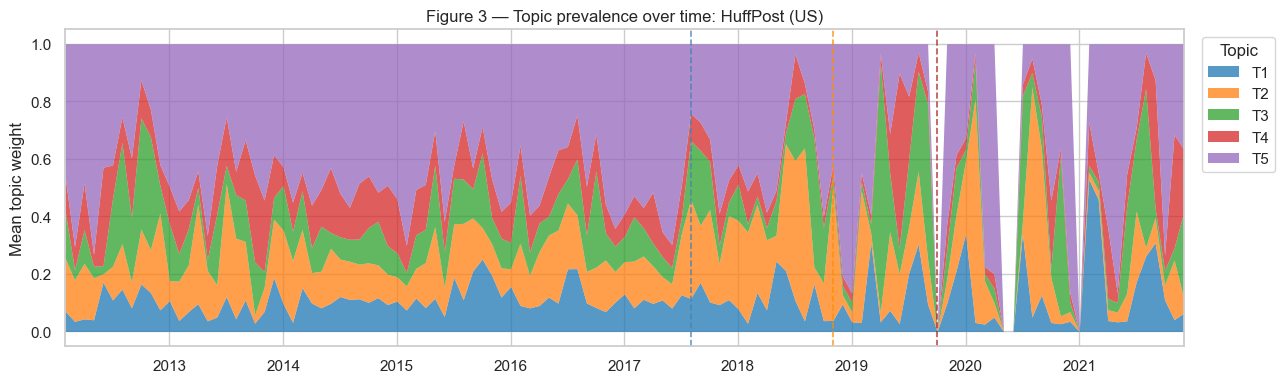

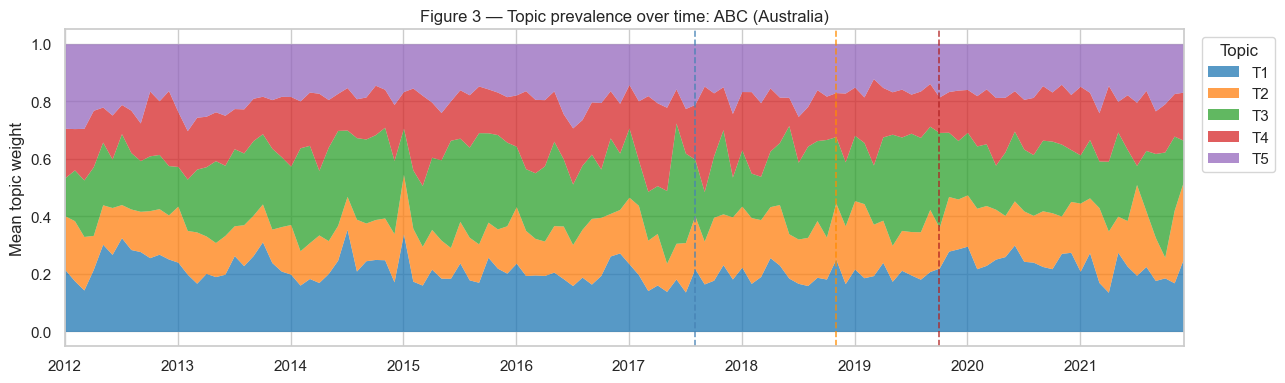

In [14]:
def topic_prevalence_over_time(lda, vec, docs, dates, outlet_label, colors=None):
    """Plot monthly topic prevalence as a stacked area chart."""
    dtm  = vec.transform(docs)
    dist = lda.transform(dtm)          # shape: (n_docs, n_topics)
    topic_df = pd.DataFrame(dist, columns=[f"T{i+1}" for i in range(dist.shape[1])])
    topic_df["date"] = pd.to_datetime(dates).values
    monthly = topic_df.set_index("date").resample("M").mean()

    if colors is None:
        colors = plt.cm.tab10.colors[:dist.shape[1]]

    fig, ax = plt.subplots(figsize=(13, 4))
    monthly.plot.area(ax=ax, color=colors, alpha=0.75, linewidth=0)
    for ev in EVENTS:
        ax.axvline(pd.Timestamp(ev["date"]), color=ev["color"],
                   linestyle="--", lw=1.2, alpha=0.8)
    ax.set_title(f"Figure 3 — Topic prevalence over time: {outlet_label}")
    ax.set_ylabel("Mean topic weight")
    ax.set_xlabel("")
    ax.legend(title="Topic", bbox_to_anchor=(1.01, 1), loc="upper left")
    plt.tight_layout()
    fname = f"fig_lda_time_{outlet_label.split()[0].lower()}.png"
    plt.savefig(os.path.join(OUTPUTS, fname), dpi=150)
    plt.show()

topic_prevalence_over_time(
    lda_hp,  vec_hp,  hp_docs,
    huffpost_sent["publish_date"].tolist(), "HuffPost (US)"
)
topic_prevalence_over_time(
    lda_abc, vec_abc, abc_docs,
    abc_sent["publish_date"].tolist(), "ABC (Australia)"
)

---
## Step 6 — Disaster Severity Correlation

Do *bigger* disasters trigger *more* or *gloomier* coverage? We build a simple monthly severity index for each country by summing the total deaths and total economic damage of all EM-DAT events active in that month, then correlate these with our two media metrics (headline share and mean sentiment).

A correlation close to **+1 or −1** would mean a strong relationship; close to **0** means the two variables move independently. Either result is valid for our essay — the point is to interpret it honestly.

**What to look for:** We might expect frequency to correlate positively with severity (more deaths → more coverage) and sentiment to correlate negatively (more deaths → more negative headlines). But this is not guaranteed.

In [15]:
def build_monthly_severity(emdat_df, iso):
    """
    For each year-month, sum Total Deaths and Total Damage of all events
    that *start* in that month for the given country.
    (Using start month as a simple proxy for peak media salience.)
    """
    sub = emdat_df[emdat_df["ISO"] == iso].copy()
    sub = sub.dropna(subset=["Start Year", "Start Month"])
    sub["year_month"] = pd.to_datetime(
        sub["Start Year"].astype(int).astype(str) + "-" +
        sub["Start Month"].astype(int).astype(str).str.zfill(2)
    ).dt.to_period("M")

    sev = sub.groupby("year_month").agg(
        deaths=("Total Deaths", "sum"),
        damage=("Total Damage ('000 US$)", "sum"),
    ).reset_index()
    sev["year_month"] = sev["year_month"].dt.to_timestamp()
    return sev.set_index("year_month")

sev_usa = build_monthly_severity(emdat, "USA")
sev_aus = build_monthly_severity(emdat, "AUS")

print("USA severity sample:")
print(sev_usa.sort_values("deaths", ascending=False).head(5))

USA severity sample:
            deaths      damage
year_month                    
2021-06-01   243.0   1335000.0
2021-02-01   236.0  30150000.0
2012-06-01   165.0  28284000.0
2021-08-01   128.0  70025000.0
2017-09-01   101.0  57000000.0


In [20]:
def merge_severity_media(monthly_media, severity):
    # resample("M") gives month-end timestamps; severity uses month-start.
    # Normalise both to month-start before joining.
    media = monthly_media.copy()
    media.index = media.index.to_period("M").to_timestamp()
    merged = media.join(severity, how="left")
    merged[["deaths", "damage"]] = merged[["deaths", "damage"]].fillna(0)
    return merged

hp_merged  = merge_severity_media(hp_monthly,  sev_usa)
abc_merged = merge_severity_media(abc_monthly, sev_aus)

# Compute Spearman correlations
pairs = [
    ("HuffPost", "Deaths",  hp_merged,  "deaths",  "share"),
    ("HuffPost", "Deaths",  hp_merged,  "deaths",  "mean_compound"),
    ("HuffPost", "Damage",  hp_merged,  "damage",  "share"),
    ("HuffPost", "Damage",  hp_merged,  "damage",  "mean_compound"),
    ("ABC",      "Deaths",  abc_merged, "deaths",  "share"),
    ("ABC",      "Deaths",  abc_merged, "deaths",  "mean_compound"),
    ("ABC",      "Damage",  abc_merged, "damage",  "share"),
    ("ABC",      "Damage",  abc_merged, "damage",  "mean_compound"),
]

corr_rows = []
for outlet, sev_type, df, xcol, ycol in pairs:
    sub = df[[xcol, ycol]].dropna()
    if len(sub) >= 5:
        r, p = stats.spearmanr(sub[xcol], sub[ycol])
    else:
        r, p = np.nan, np.nan
    corr_rows.append({"Outlet": outlet, "Severity": sev_type,
                      "Media metric": ycol, "Spearman r": round(r, 3), "p-value": round(p, 3)})

corr_table = pd.DataFrame(corr_rows)
print(corr_table.to_string(index=False))

  Outlet Severity  Media metric  Spearman r  p-value
HuffPost   Deaths         share       0.052    0.577
HuffPost   Deaths mean_compound      -0.134    0.153
HuffPost   Damage         share      -0.025    0.790
HuffPost   Damage mean_compound      -0.147    0.118
     ABC   Deaths         share       0.405    0.000
     ABC   Deaths mean_compound      -0.001    0.987
     ABC   Damage         share       0.501    0.000
     ABC   Damage mean_compound      -0.070    0.448


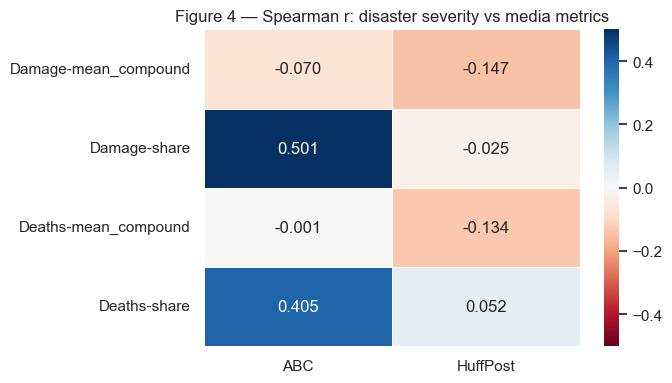

In [21]:
# Pivot into a heatmap-friendly format (share and sentiment as rows, outlets as cols)
pivot_r = corr_table.pivot_table(
    index=["Severity", "Media metric"], columns="Outlet", values="Spearman r"
)

fig, ax = plt.subplots(figsize=(7, 4))
sns.heatmap(
    pivot_r, annot=True, fmt=".3f", center=0,
    cmap="RdBu", linewidths=0.5, ax=ax,
    vmin=-0.5, vmax=0.5
)
ax.set_title("Figure 4 — Spearman r: disaster severity vs media metrics")
ax.set_xlabel("")
ax.set_ylabel("")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "fig_severity_heatmap.png"), dpi=150)
plt.show()

---
## Step 7 — Summary Comparison Table

This table brings together the event-study results in a compact, essay-ready format. For each case-study event and each outlet, it shows the average climate headline share and sentiment in the **three months before** vs **three months after** the disaster, and whether the post-event change was larger for the "home country" outlet.

This directly addresses **Research Question 3** — are there differences in the intensity and sentiment of HuffPost and ABC coverage, and how do these relate to country-specific disaster exposure?

In [22]:
rows = []

for cs in CASE_STUDIES:
    for outlet in OUTLETS:
        mdf = outlet["monthly"]
        ev_win = get_event_window(mdf, cs["year"], cs["month"], LAG)
        if ev_win.empty:
            continue
        ev_win = ev_win.reset_index()
        ev_win["offset"] = list(range(-LAG, -LAG + len(ev_win)))

        pre  = ev_win[ev_win["offset"].between(-LAG, -1)]
        post = ev_win[ev_win["offset"].between(1, LAG)]

        home = (cs["iso"] == outlet["iso"])

        rows.append({
            "Event":           cs["name"],
            "Outlet":          outlet["label"],
            "Home outlet":     "Yes" if home else "No",
            "Pre share (%)": round(pre["share"].mean(), 2) if len(pre) else np.nan,
            "Post share (%)": round(post["share"].mean(), 2) if len(post) else np.nan,
            "Δ share":         round(post["share"].mean() - pre["share"].mean(), 2)
                                if len(pre) and len(post) else np.nan,
            "Pre sentiment":  round(pre["mean_compound"].mean(), 3) if len(pre) else np.nan,
            "Post sentiment": round(post["mean_compound"].mean(), 3) if len(post) else np.nan,
            "Δ sentiment":    round(post["mean_compound"].mean() - pre["mean_compound"].mean(), 3)
                               if len(pre) and len(post) else np.nan,
        })

summary = pd.DataFrame(rows)
summary.to_csv(os.path.join(PROCESSED, "summary_comparison.csv"), index=False)

# Display nicely
print("=== Table 1 — Event-study summary: pre vs post disaster ===")
print(summary.to_string(index=False))

=== Table 1 — Event-study summary: pre vs post disaster ===
                 Event          Outlet Home outlet  Pre share (%)  Post share (%)  Δ share  Pre sentiment  Post sentiment  Δ sentiment
    Black Summer (AUS)   HuffPost (US)          No           4.93            4.76    -0.18         -0.323          -0.270        0.053
    Black Summer (AUS) ABC (Australia)         Yes           3.58           11.02     7.44         -0.089          -0.149       -0.060
       Camp Fire (USA)   HuffPost (US)         Yes           5.15            1.76    -3.39         -0.204          -0.043        0.161
       Camp Fire (USA) ABC (Australia)          No           3.04            4.41     1.37         -0.088          -0.081        0.007
Hurricane Harvey (USA)   HuffPost (US)         Yes           3.39            5.04     1.65         -0.087          -0.081        0.006
Hurricane Harvey (USA) ABC (Australia)          No           1.55            1.93     0.37         -0.040          -0.076       -0

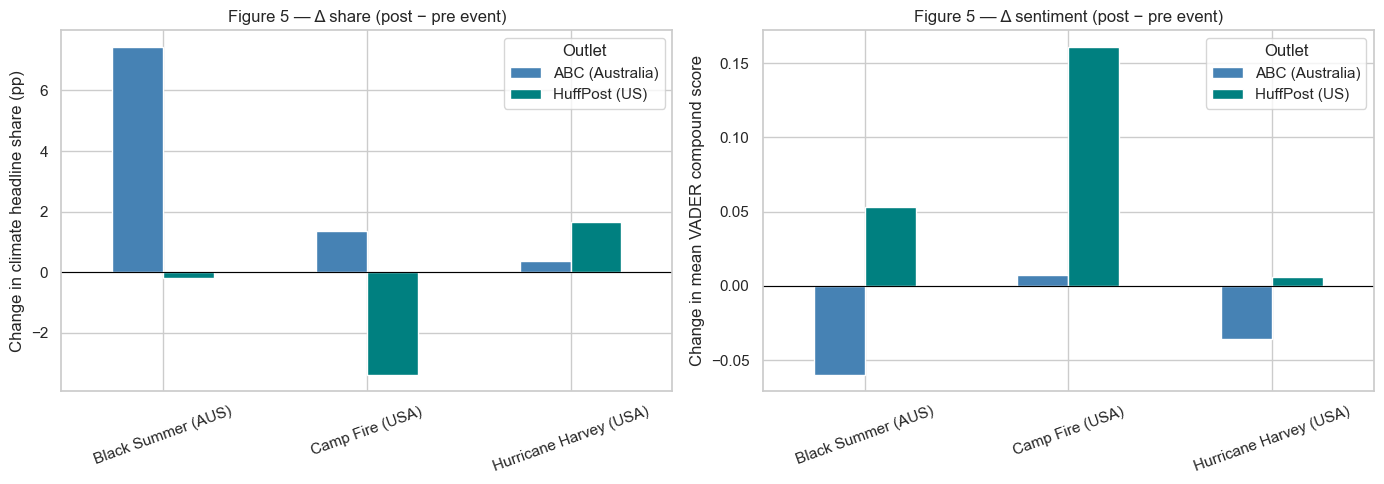

In [23]:
# Quick bar chart of Δ share and Δ sentiment by event and outlet
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, metric, ylabel in [
    (axes[0], "Δ share",     "Change in climate headline share (pp)"),
    (axes[1], "Δ sentiment", "Change in mean VADER compound score"),
]:
    pivot = summary.pivot(index="Event", columns="Outlet", values=metric)
    pivot.plot(kind="bar", ax=ax, color=["steelblue", "teal"], edgecolor="white")
    ax.axhline(0, color="black", lw=0.8)
    ax.set_title(f"Figure 5 — {metric} (post − pre event)")
    ax.set_ylabel(ylabel)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(title="Outlet")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUTS, "fig_summary_bars.png"), dpi=150)
plt.show()

---
### File descriptions

| File | Description |
|---|---|
| `huffpost_all.csv` | All HuffPost headlines 2012–2021 (filtered categories) |
| `huffpost_climate.csv` | Climate-relevant HuffPost headlines |
| `huffpost_sentiment.csv` | Climate headlines + VADER scores |
| `abc_all.csv` | All ABC Australia headlines 2012–2021 |
| `abc_climate.csv` | Climate-relevant ABC headlines |
| `abc_sentiment.csv` | Climate headlines + VADER scores |
| `emdat_clean.csv` | EM-DAT natural disasters (numerics fixed) |
| `summary_comparison.csv` | Pre/post event-study table |
| `fig_*.png` | All figures |